In [34]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNet,
    InceptionV3, EfficientNetB0
)
from tensorflow.keras.applications import (
    vgg16, resnet50, mobilenet,
    inception_v3, efficientnet
)

# Reproducibility — set all seeds
SEED = 42
os.environ['PYTHONHASHSEED']    = str(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ All imports successful")


✅ All imports successful


In [ ]:
# Paths
BASE_DIR   = r"/Users/dheivasubramanian/Downloads/AIML_GUVI/Fish Image Classification/DATA/data"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
VAL_DIR    = os.path.join(BASE_DIR, "val")
TEST_DIR   = os.path.join(BASE_DIR, "test")

# Model config
IMG_SIZE    = 224
BATCH_SIZE  = 32        # ✅ Updated
NUM_CLASSES = 11
AUTOTUNE    = tf.data.AUTOTUNE

print(f"Train path exists : {os.path.exists(TRAIN_DIR)}")
print(f"Val   path exists : {os.path.exists(VAL_DIR)}")
print(f"Test  path exists : {os.path.exists(TEST_DIR)}")


Train path exists : True
Val   path exists : True
Test  path exists : True


In [37]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
print(f"Total Classes ({len(CLASS_NAMES)}) : {CLASS_NAMES}")
print(f"Train batches : {len(train_ds)}")
print(f"Val   batches : {len(val_ds)}")
print(f"Test  batches : {len(test_ds)}")


Found 6225 files belonging to 11 classes.
Found 1092 files belonging to 11 classes.
Found 3187 files belonging to 11 classes.
Total Classes (11) : ['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']
Train batches : 195
Val   batches : 35
Test  batches : 100


In [38]:
print("📊 Class Distribution:\n")
for split, path in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(f"  [{split}]")
    for cls in sorted(os.listdir(path)):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            print(f"    {cls:<45} : {count} images")
    print()


📊 Class Distribution:

  [TRAIN]
    animal fish                                   : 1096 images
    animal fish bass                              : 30 images
    fish sea_food black_sea_sprat                 : 569 images
    fish sea_food gilt_head_bream                 : 566 images
    fish sea_food hourse_mackerel                 : 573 images
    fish sea_food red_mullet                      : 579 images
    fish sea_food red_sea_bream                   : 571 images
    fish sea_food sea_bass                        : 538 images
    fish sea_food shrimp                          : 576 images
    fish sea_food striped_red_mullet              : 547 images
    fish sea_food trout                           : 580 images

  [VAL]
    animal fish                                   : 187 images
    animal fish bass                              : 10 images
    fish sea_food black_sea_sprat                 : 105 images
    fish sea_food gilt_head_bream                 : 94 images
    fish sea_fo

In [39]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2),
], name="data_augmentation")

rescaling = layers.Rescaling(1./255)

# Custom CNN — augment + rescale to [0,1]
def preprocess_train_custom(image, label):
    image = data_augmentation(image, training=True)
    image = rescaling(image)
    return image, label

def preprocess_eval_custom(image, label):
    return rescaling(image), label

# Transfer models — augment only, preprocess_input inside model
def preprocess_train_transfer(image, label):
    image = data_augmentation(image, training=True)
    return image, label

def preprocess_eval_transfer(image, label):
    return image, label

print("✅ Augmentation pipeline defined")


✅ Augmentation pipeline defined


In [40]:
# Custom CNN pipelines
train_ds_custom = (train_ds
    .map(preprocess_train_custom, num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE))

val_ds_custom = (val_ds
    .map(preprocess_eval_custom, num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE))

# Transfer learning pipelines (raw pixels)
train_ds_transfer = (train_ds
    .map(preprocess_train_transfer, num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE))

val_ds_transfer = (val_ds
    .map(preprocess_eval_transfer, num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE))

# Test pipelines (no cache — used once only)
test_ds_custom   = (test_ds
    .map(preprocess_eval_custom, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

test_ds_transfer = (test_ds
    .map(preprocess_eval_transfer, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

print("✅ All dataset pipelines ready")


✅ All dataset pipelines ready


In [41]:
for images, labels in train_ds_custom.take(1):
    print("── Custom CNN Pipeline ──")
    print("Image shape :", images.shape)         # (32, 224, 224, 3)
    print("Label shape :", labels.shape)         # (32, 11)
    print("Pixel range : [{:.4f}, {:.4f}]".format(
        float(images.numpy().min()),
        float(images.numpy().max())              # Must be [0.0, 1.0]
    ))

for images, labels in train_ds_transfer.take(1):
    print("\n── Transfer Pipeline ──")
    print("Image shape :", images.shape)         # (32, 224, 224, 3)
    print("Pixel range : [{:.4f}, {:.4f}]".format(
        float(images.numpy().min()),
        float(images.numpy().max())              # Raw [0.0, 255.0]
    ))

for images, _ in train_ds_custom.take(5):
    assert not tf.reduce_any(tf.math.is_nan(images)), "❌ NaN found!"
print("\n✅ No NaN | Sanity check passed")


── Custom CNN Pipeline ──
Image shape : (32, 224, 224, 3)
Label shape : (32, 11)
Pixel range : [0.0000, 1.0000]


2026-03-07 16:42:39.588269: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



── Transfer Pipeline ──
Image shape : (32, 224, 224, 3)
Pixel range : [0.0000, 255.0000]


2026-03-07 16:42:39.983110: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



✅ No NaN | Sanity check passed


2026-03-07 16:42:40.499493: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Found 6225 files belonging to 11 classes.


2026-03-07 16:42:58.399367: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


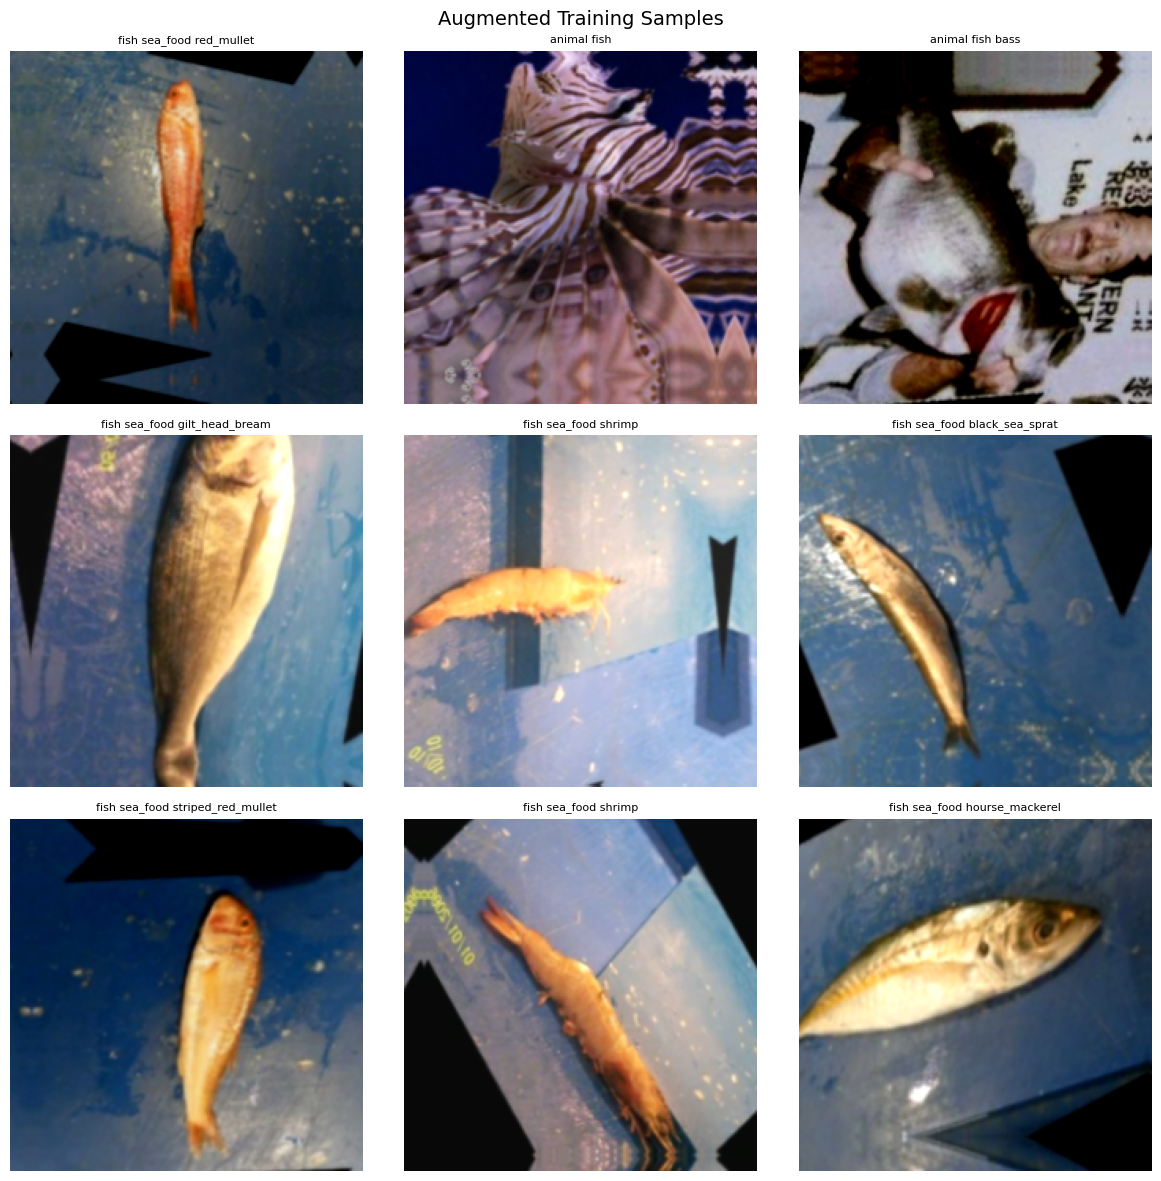

In [42]:
raw_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=9, label_mode="categorical", seed=SEED
)

plt.figure(figsize=(12, 12))
for images, labels in raw_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        aug_img = data_augmentation(
            tf.expand_dims(images[i], 0), training=True
        )
        plt.imshow(aug_img[0].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[tf.argmax(labels[i]).numpy()], fontsize=8)
        plt.axis("off")

plt.suptitle("Augmented Training Samples", fontsize=14)
plt.tight_layout()
plt.show()


In [46]:
os.makedirs("saved_models", exist_ok=True)

# For Custom CNN — CosineDecay handles LR, no ReduceLROnPlateau
def get_callbacks(model_name, patience_es=8):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=f"saved_models/{model_name}_best.keras",
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=patience_es,
            restore_best_weights=True,
            verbose=1
        )
        # ✅ ReduceLROnPlateau removed — incompatible with CosineDecay
    ]

# For Transfer models — float LR, ReduceLROnPlateau is safe
def get_callbacks_transfer(model_name, patience_es=8, patience_lr=3):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=f"saved_models/{model_name}_best.keras",
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=patience_es,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-7,
            verbose=1
        )
    ]

def plot_history(history, model_name):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, acc,     'b-o', label='Train Accuracy')
    ax1.plot(epochs, val_acc, 'r-o', label='Val Accuracy')
    ax1.set_title(f'{model_name} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, loss,     'b-o', label='Train Loss')
    ax2.plot(epochs, val_loss, 'r-o', label='Val Loss')
    ax2.set_title(f'{model_name} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"saved_models/{model_name}_history.png", dpi=150)
    plt.show()
    print(f"✅ Plot saved: saved_models/{model_name}_history.png")

print("✅ Callbacks and plot helper ready")


✅ Callbacks and plot helper ready


In [47]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_custom_cnn(num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)

    x = residual_block(x, 64);  x = layers.MaxPooling2D(2,2)(x)
    x = residual_block(x, 128); x = layers.MaxPooling2D(2,2)(x)
    x = residual_block(x, 256); x = layers.MaxPooling2D(2,2)(x)
    x = residual_block(x, 512); x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="custom_cnn")

custom_cnn = build_custom_cnn()
custom_cnn.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 224, 224,  │        896 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 112, 112,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 112, 112,  │      2,112 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 112, 112,  │          0 │ add_4[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 56, 56,    │          0 │ activation_4[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 56, 56,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 56, 56,    │      8,320 │ max_pooling2d_9[

 Total params: 5,019,979 (19.15 MB)

 Trainable params: 5,016,075 (19.13 MB)

 Non-trainable params: 3,904 (15.25 KB)


Training Custom CNN
Epoch 1/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.3015 - loss: 2.8429
Epoch 1: val_accuracy improved from None to 0.10806, saving model to saved_models/custom_cnn_best.keras

Epoch 1: finished saving model to saved_models/custom_cnn_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 117s 570ms/step - accuracy: 0.3812 - loss: 2.4596 - val_accuracy: 0.1081 - val_loss: 8.3386
Epoch 2/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.5136 - loss: 2.0090
Epoch 2: val_accuracy improved from 0.10806 to 0.29487, saving model to saved_models/custom_cnn_best.keras

Epoch 2: finished saving model to saved_models/custom_cnn_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 119s 609ms/step - accuracy: 0.5219 - loss: 1.9901 - val_accuracy: 0.2949 - val_loss: 4.8127
Epoch 3/50
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.5906 - loss: 1.8109
Epoch 3: val_accuracy improved from 0.29487 to 0.71520, saving model to saved_models/custom_cnn_best.keras

Epoch 3: finis

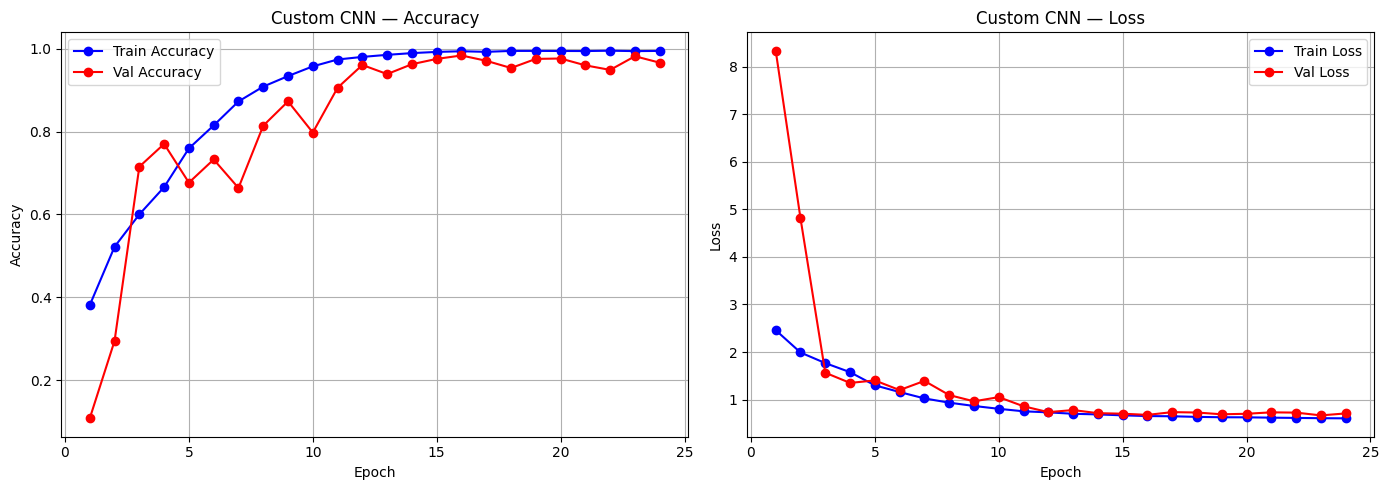

✅ Plot saved: saved_models/Custom CNN_history.png


In [48]:
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=len(train_ds_custom) * 50,
    alpha=1e-6
)

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(lr_schedule),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("\n" + "="*55)
print("Training Custom CNN")
print("="*55)

cnn_history = custom_cnn.fit(
    train_ds_custom,
    validation_data=val_ds_custom,
    epochs=50,
    callbacks=get_callbacks("custom_cnn") 
)

cnn_best_acc = max(cnn_history.history['val_accuracy'])
print(f"\n✅ Custom CNN — Best Val Accuracy: {cnn_best_acc:.4f}")
plot_history(cnn_history, "Custom CNN")


In [49]:
model_preprocess = {
    "VGG16":          vgg16.preprocess_input,
    "ResNet50":       resnet50.preprocess_input,
    "MobileNet":      mobilenet.preprocess_input,
    "InceptionV3":    inception_v3.preprocess_input,
    "EfficientNetB0": efficientnet.preprocess_input,
}

def build_transfer_model(base_model, model_name,
                         input_size=IMG_SIZE, num_classes=NUM_CLASSES):
    base_model.trainable = False

    inputs  = keras.Input(shape=(input_size, input_size, 3))
    x       = model_preprocess[model_name](inputs)
    x       = base_model(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(0.001))(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name=model_name), base_model

print("✅ Transfer model builder ready")


✅ Transfer model builder ready


In [50]:
model_zoo = {
    "VGG16": VGG16(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    "ResNet50": ResNet50(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    "MobileNet": MobileNet(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    "EfficientNetB0": EfficientNetB0(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
}

inception_base = InceptionV3(
    include_top=False, weights='imagenet',
    input_shape=(299, 299, 3)
)

print("✅ All 5 base models loaded with ImageNet weights")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
✅ All 5 base models loaded with ImageNet weights


In [51]:
train_ds_299 = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(299,299), batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=True, seed=SEED
)
val_ds_299 = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(299,299), batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=False
)

train_ds_299 = (train_ds_299
    .map(lambda img, lbl: (data_augmentation(img, training=True), lbl),
         num_parallel_calls=AUTOTUNE)
    .cache().prefetch(AUTOTUNE))

val_ds_299 = val_ds_299.cache().prefetch(AUTOTUNE)

print("✅ InceptionV3 299×299 datasets ready")


Found 6225 files belonging to 11 classes.
Found 1092 files belonging to 11 classes.
✅ InceptionV3 299×299 datasets ready


In [56]:

def get_callbacks_transfer(model_name, patience_es=4, patience_lr=2):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=f"saved_models/{model_name}_best.keras",
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=patience_es,        
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=patience_lr,        
            min_lr=1e-7,
            verbose=1
        )
    ]

In [60]:
def train_transfer_model(base_model, model_name,
                         t_ds=None, v_ds=None, input_size=IMG_SIZE):
    t_ds = t_ds or train_ds_transfer
    v_ds = v_ds or val_ds_transfer

    model, base = build_transfer_model(base_model, model_name, input_size)

    # ✅ Unfreeze last 50% immediately — no Phase 1
    base.trainable = True
    fine_tune_from = int(len(base.layers) * 0.5)
    for layer in base.layers[:fine_tune_from]:
        layer.trainable = False

    # ✅ Single compile — balanced LR between 1e-3 and 2e-5
    model.compile(
        optimizer=keras.optimizers.Adam(5e-5),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    print(f"\n{'='*55}")
    print(f"[{model_name}] 10 epochs")
    print(f"{'='*55}")

    history = model.fit(
        t_ds,
        validation_data=v_ds,
        epochs=10,                  # ✅ Single run of 10 epochs
        callbacks=get_callbacks_transfer(f"{model_name}_best")
    )

    best_acc = max(history.history['val_accuracy'])
    plot_history(history, model_name)
    print(f"\n✅ [{model_name}] Best Val Accuracy: {best_acc:.4f}")
    return model, best_acc

print("✅ Single phase training function ready")


✅ Single phase training function ready



[VGG16] 10 epochs
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 873ms/step - accuracy: 0.7112 - loss: 1.7917
Epoch 1: val_accuracy improved from None to 0.94597, saving model to saved_models/VGG16_best_best.keras

Epoch 1: finished saving model to saved_models/VGG16_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 190s 966ms/step - accuracy: 0.8627 - loss: 1.3734 - val_accuracy: 0.9460 - val_loss: 1.2251 - learning_rate: 5.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9634 - loss: 1.1018
Epoch 2: val_accuracy improved from 0.94597 to 0.97985, saving model to saved_models/VGG16_best_best.keras

Epoch 2: finished saving model to saved_models/VGG16_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 249s 1s/step - accuracy: 0.9669 - loss: 1.0888 - val_accuracy: 0.9799 - val_loss: 1.1364 - learning_rate: 5.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9769 - loss: 1.0590
Epoch 3: val_accuracy did not improve from 0.97985
195/195 ━━━━━━━━━━━━━━━━━━

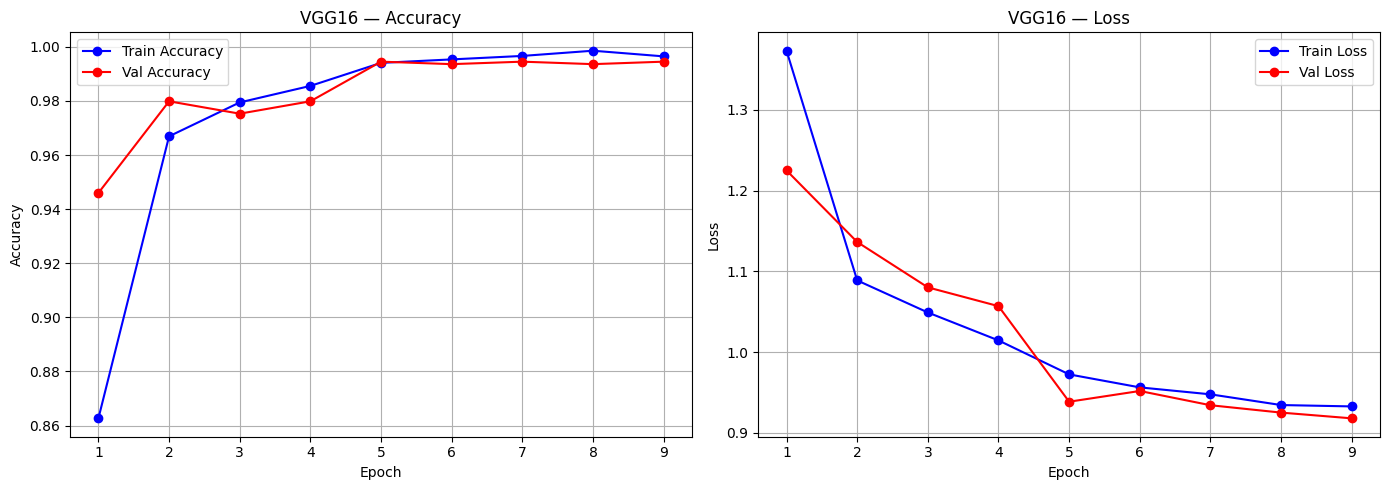

✅ Plot saved: saved_models/VGG16_history.png

✅ [VGG16] Best Val Accuracy: 0.9945

[ResNet50] 10 epochs
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.6100 - loss: 2.3940
Epoch 1: val_accuracy improved from None to 0.96062, saving model to saved_models/ResNet50_best_best.keras

Epoch 1: finished saving model to saved_models/ResNet50_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 164s 748ms/step - accuracy: 0.7900 - loss: 1.7963 - val_accuracy: 0.9606 - val_loss: 1.3008 - learning_rate: 5.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.9507 - loss: 1.3488
Epoch 2: val_accuracy improved from 0.96062 to 0.97802, saving model to saved_models/ResNet50_best_best.keras

Epoch 2: finished saving model to saved_models/ResNet50_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 131s 674ms/step - accuracy: 0.9475 - loss: 1.3260 - val_accuracy: 0.9780 - val_loss: 1.2712 - learning_rate: 5.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - acc

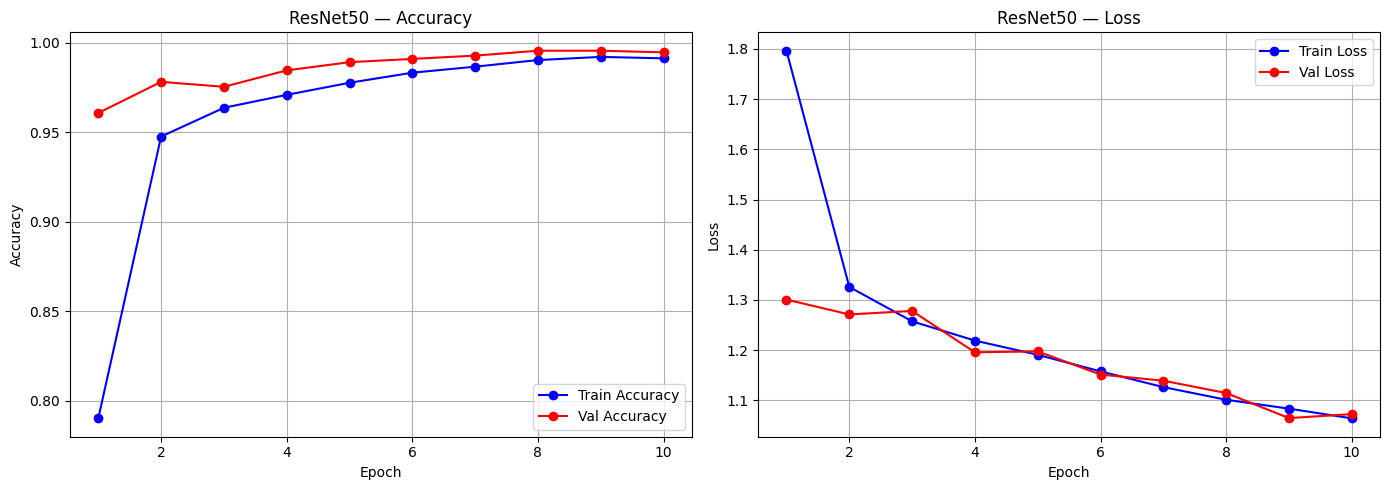

✅ Plot saved: saved_models/ResNet50_history.png

✅ [ResNet50] Best Val Accuracy: 0.9954

[MobileNet] 10 epochs
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.4192 - loss: 2.8903
Epoch 1: val_accuracy improved from None to 0.92949, saving model to saved_models/MobileNet_best_best.keras

Epoch 1: finished saving model to saved_models/MobileNet_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 71s 326ms/step - accuracy: 0.6076 - loss: 2.1856 - val_accuracy: 0.9295 - val_loss: 1.2875 - learning_rate: 5.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8700 - loss: 1.4497
Epoch 2: val_accuracy improved from 0.92949 to 0.96337, saving model to saved_models/MobileNet_best_best.keras

Epoch 2: finished saving model to saved_models/MobileNet_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 58s 296ms/step - accuracy: 0.8778 - loss: 1.4196 - val_accuracy: 0.9634 - val_loss: 1.2380 - learning_rate: 5.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/s

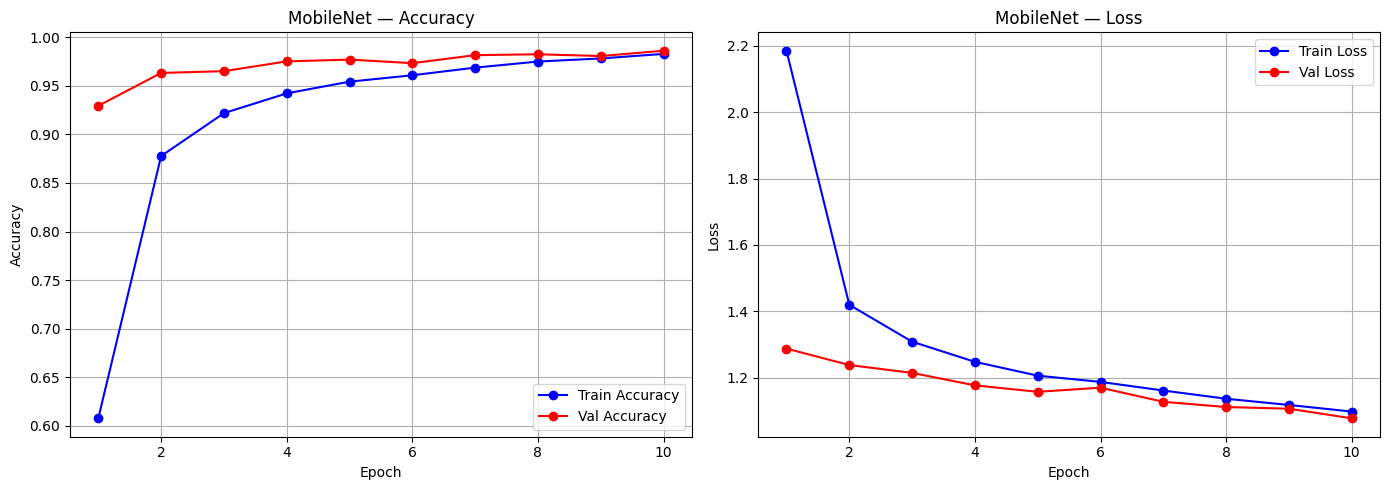

✅ Plot saved: saved_models/MobileNet_history.png

✅ [MobileNet] Best Val Accuracy: 0.9863

[EfficientNetB0] 10 epochs
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3877 - loss: 3.0644
Epoch 1: val_accuracy improved from None to 0.92033, saving model to saved_models/EfficientNetB0_best_best.keras

Epoch 1: finished saving model to saved_models/EfficientNetB0_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 1060s 5s/step - accuracy: 0.5790 - loss: 2.3127 - val_accuracy: 0.9203 - val_loss: 1.2694 - learning_rate: 5.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.8522 - loss: 1.5088
Epoch 2: val_accuracy improved from 0.92033 to 0.96337, saving model to saved_models/EfficientNetB0_best_best.keras

Epoch 2: finished saving model to saved_models/EfficientNetB0_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 109s 555ms/step - accuracy: 0.8644 - loss: 1.4765 - val_accuracy: 0.9634 - val_loss: 1.3036 - learning_rate: 5.0000e-05
Epoch 3/10
195/195 ━━━━━━━

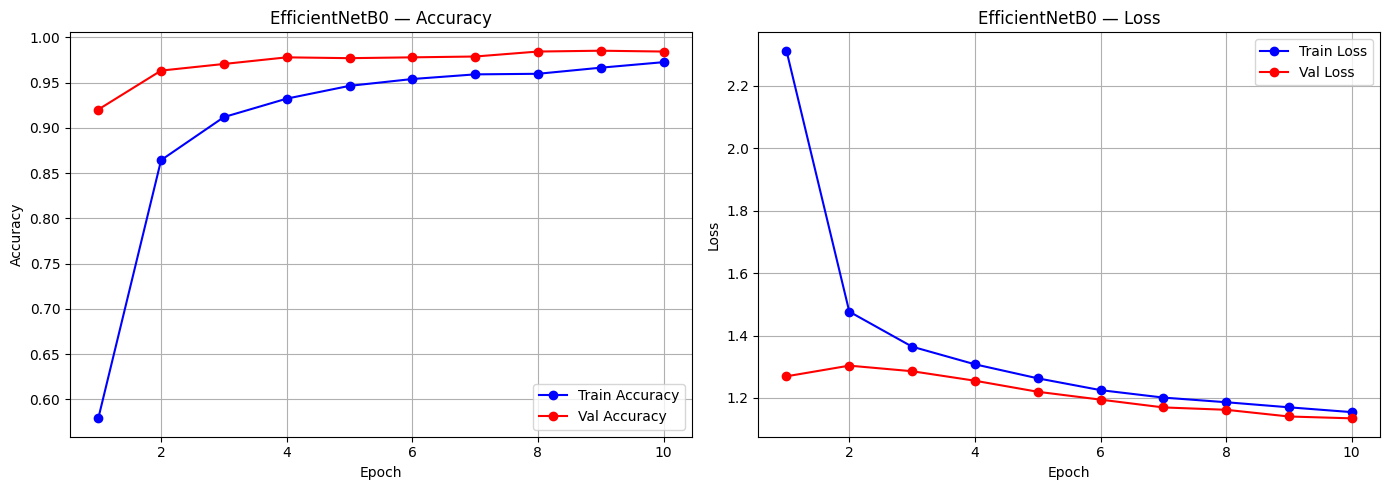

✅ Plot saved: saved_models/EfficientNetB0_history.png

✅ [EfficientNetB0] Best Val Accuracy: 0.9853

[InceptionV3] 10 epochs
Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6367 - loss: 2.3045
Epoch 1: val_accuracy improved from None to 0.96795, saving model to saved_models/InceptionV3_best_best.keras

Epoch 1: finished saving model to saved_models/InceptionV3_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.7971 - loss: 1.7819 - val_accuracy: 0.9679 - val_loss: 1.1813 - learning_rate: 5.0000e-05
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.9507 - loss: 1.3431
Epoch 2: val_accuracy improved from 0.96795 to 0.97619, saving model to saved_models/InceptionV3_best_best.keras

Epoch 2: finished saving model to saved_models/InceptionV3_best_best.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 192s 985ms/step - accuracy: 0.9489 - loss: 1.3167 - val_accuracy: 0.9762 - val_loss: 1.1891 - learning_rate: 5.0000e-05
Epoch 3/10
195/195 ━━━━━━━━━━━━━

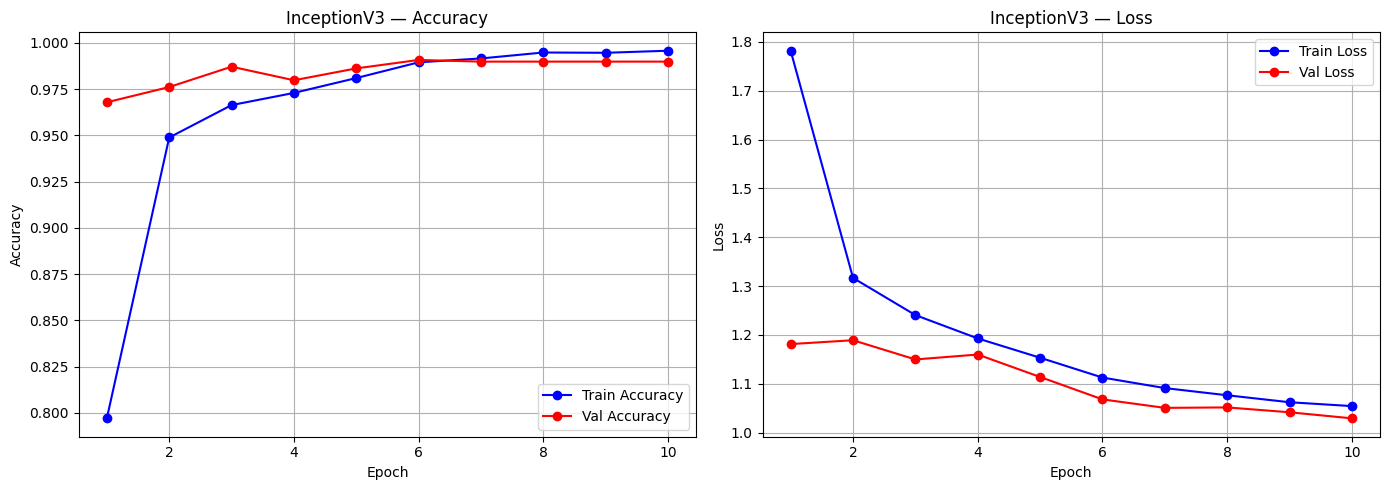

✅ Plot saved: saved_models/InceptionV3_history.png

✅ [InceptionV3] Best Val Accuracy: 0.9908

📊 MODEL LEADERBOARD
  ResNet50           → 0.9954  ███████████████████████████████████████
  VGG16              → 0.9945  ███████████████████████████████████████
  InceptionV3        → 0.9908  ███████████████████████████████████████
  MobileNet          → 0.9863  ███████████████████████████████████████
  EfficientNetB0     → 0.9853  ███████████████████████████████████████
  CustomCNN          → 0.9835  ███████████████████████████████████████


In [61]:
results = {}

for model_name, base_model in model_zoo.items():
    trained_model, best_acc = train_transfer_model(base_model, model_name)
    results[model_name] = {"model": trained_model, "val_acc": best_acc}

inception_model, inception_acc = train_transfer_model(
    inception_base, "InceptionV3",
    t_ds=train_ds_299, v_ds=val_ds_299, input_size=299
)
results["InceptionV3"] = {"model": inception_model, "val_acc": inception_acc}

results["CustomCNN"] = {"model": custom_cnn, "val_acc": cnn_best_acc}

print("\n" + "="*55)
print("📊 MODEL LEADERBOARD")
print("="*55)
for name, res in sorted(results.items(),
                        key=lambda x: x[1]['val_acc'], reverse=True):
    bar = "█" * int(res['val_acc'] * 40)
    print(f"  {name:<18} → {res['val_acc']:.4f}  {bar}")


In [62]:
best_name  = max(results, key=lambda k: results[k]['val_acc'])
best_acc   = results[best_name]['val_acc']
best_model = results[best_name]['model']

print(f"🏆 Best Model   : {best_name}")
print(f"🎯 Val Accuracy : {best_acc:.4f}")

best_model.save(f"saved_models/best_model_{best_name}.keras")
best_model.save(f"saved_models/best_model_{best_name}.h5")

print(f"\n✅ Saved:")
print(f"   saved_models/best_model_{best_name}.keras")
print(f"   saved_models/best_model_{best_name}.h5")


🏆 Best Model   : ResNet50
🎯 Val Accuracy : 0.9954



✅ Saved:
   saved_models/best_model_ResNet50.keras
   saved_models/best_model_ResNet50.h5


In [63]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np
import matplotlib.pyplot as plt

print("✅ Evaluation imports ready")


✅ Evaluation imports ready


In [64]:
def get_predictions(model, dataset):
    """
    Runs model on dataset and returns
    true labels and predicted labels as numpy arrays
    """
    y_true, y_pred = [], []

    for images, labels in dataset:
        preds    = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds,          axis=1))

    return np.array(y_true), np.array(y_pred)

print("✅ Prediction helper ready")


✅ Prediction helper ready


In [65]:
def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(14, 12))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=True,
        xticks_rotation=45
    )
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig(f"saved_models/{model_name}_confusion_matrix.png", dpi=150)
    plt.show()
    print(f"✅ Saved: saved_models/{model_name}_confusion_matrix.png")

print("✅ Confusion matrix helper ready")


✅ Confusion matrix helper ready


In [66]:
def print_classification_report(y_true, y_pred, model_name, class_names):
    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4
    )
    print(f"\n{'='*60}")
    print(f"  {model_name} — Classification Report")
    print(f"{'='*60}")
    print(report)
    return report

print("✅ Classification report helper ready")


✅ Classification report helper ready


In [67]:
# Map each model to its correct test pipeline
# Custom CNN uses rescaled [0,1] pipeline
# Transfer models use raw [0,255] pipeline

eval_results = {}

for name, res in results.items():
    print(f"\n🔍 Evaluating: {name}")

    # Pick correct test dataset
    if name == "CustomCNN":
        test_pipeline = test_ds_custom
    elif name == "InceptionV3":
        # InceptionV3 needs 299×299 test dataset
        test_pipeline = tf.keras.utils.image_dataset_from_directory(
            TEST_DIR, image_size=(299,299), batch_size=BATCH_SIZE,
            label_mode="categorical", shuffle=False
        ).prefetch(AUTOTUNE)
    else:
        test_pipeline = test_ds_transfer

    # Get predictions
    y_true, y_pred = get_predictions(res['model'], test_pipeline)

    # Store for later
    eval_results[name] = {
        "y_true" : y_true,
        "y_pred" : y_pred,
        "val_acc": res['val_acc']
    }

    # Print classification report
    print_classification_report(y_true, y_pred, name, CLASS_NAMES)

print("\n✅ All models evaluated on test set")



🔍 Evaluating: VGG16


2026-03-07 23:22:58.443151: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



  VGG16 — Classification Report
                                  precision    recall  f1-score   support

                     animal fish     0.9848    0.9981    0.9914       520
                animal fish bass     1.0000    0.3846    0.5556        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     1.0000    1.0000    1.0000       305
   fish sea_food hourse_mackerel     1.0000    1.0000    1.0000       286
        fish sea_food red_mullet     1.0000    1.0000    1.0000       291
     fish sea_food red_sea_bream     1.0000    1.0000    1.0000       273
          fish sea_food sea_bass     1.0000    1.0000    1.0000       327
            fish sea_food shrimp     1.0000    1.0000    1.0000       289
fish sea_food striped_red_mullet     1.0000    1.0000    1.0000       293
             fish sea_food trout     0.9966    1.0000    0.9983       292

                        accuracy                         0.9972      3187
   

2026-03-07 23:23:31.757950: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



  ResNet50 — Classification Report
                                  precision    recall  f1-score   support

                     animal fish     0.9923    0.9962    0.9942       520
                animal fish bass     0.9000    0.6923    0.7826        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     0.9967    0.9967    0.9967       305
   fish sea_food hourse_mackerel     1.0000    1.0000    1.0000       286
        fish sea_food red_mullet     0.9966    1.0000    0.9983       291
     fish sea_food red_sea_bream     0.9964    1.0000    0.9982       273
          fish sea_food sea_bass     1.0000    0.9969    0.9985       327
            fish sea_food shrimp     1.0000    1.0000    1.0000       289
fish sea_food striped_red_mullet     1.0000    1.0000    1.0000       293
             fish sea_food trout     1.0000    1.0000    1.0000       292

                        accuracy                         0.9975      3187


2026-03-07 23:23:45.778724: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



  MobileNet — Classification Report
                                  precision    recall  f1-score   support

                     animal fish     0.9808    0.9827    0.9817       520
                animal fish bass     1.0000    0.1538    0.2667        13
   fish sea_food black_sea_sprat     1.0000    1.0000    1.0000       298
   fish sea_food gilt_head_bream     0.9682    0.9967    0.9822       305
   fish sea_food hourse_mackerel     0.9930    0.9930    0.9930       286
        fish sea_food red_mullet     0.9731    0.9931    0.9830       291
     fish sea_food red_sea_bream     0.9927    1.0000    0.9964       273
          fish sea_food sea_bass     1.0000    0.9847    0.9923       327
            fish sea_food shrimp     0.9966    1.0000    0.9983       289
fish sea_food striped_red_mullet     0.9895    0.9625    0.9758       293
             fish sea_food trout     0.9832    1.0000    0.9915       292

                        accuracy                         0.9871      3187

2026-03-07 23:24:09.778504: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-07 23:24:56.160622: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



  InceptionV3 — Classification Report
                                  precision    recall  f1-score   support

                     animal fish     0.9848    1.0000    0.9924       520
                animal fish bass     1.0000    0.3846    0.5556        13
   fish sea_food black_sea_sprat     1.0000    0.9966    0.9983       298
   fish sea_food gilt_head_bream     1.0000    0.9967    0.9984       305
   fish sea_food hourse_mackerel     1.0000    1.0000    1.0000       286
        fish sea_food red_mullet     0.9897    0.9931    0.9914       291
     fish sea_food red_sea_bream     0.9964    1.0000    0.9982       273
          fish sea_food sea_bass     0.9970    1.0000    0.9985       327
            fish sea_food shrimp     1.0000    1.0000    1.0000       289
fish sea_food striped_red_mullet     0.9932    0.9898    0.9915       293
             fish sea_food trout     1.0000    1.0000    1.0000       292

                        accuracy                         0.9953      31

2026-03-07 23:25:10.589199: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/dheivasubramanian/miniforge3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dheivasubramanian/miniforge3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/dheivasubramanian/miniforge3/envs/tf-m4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricW

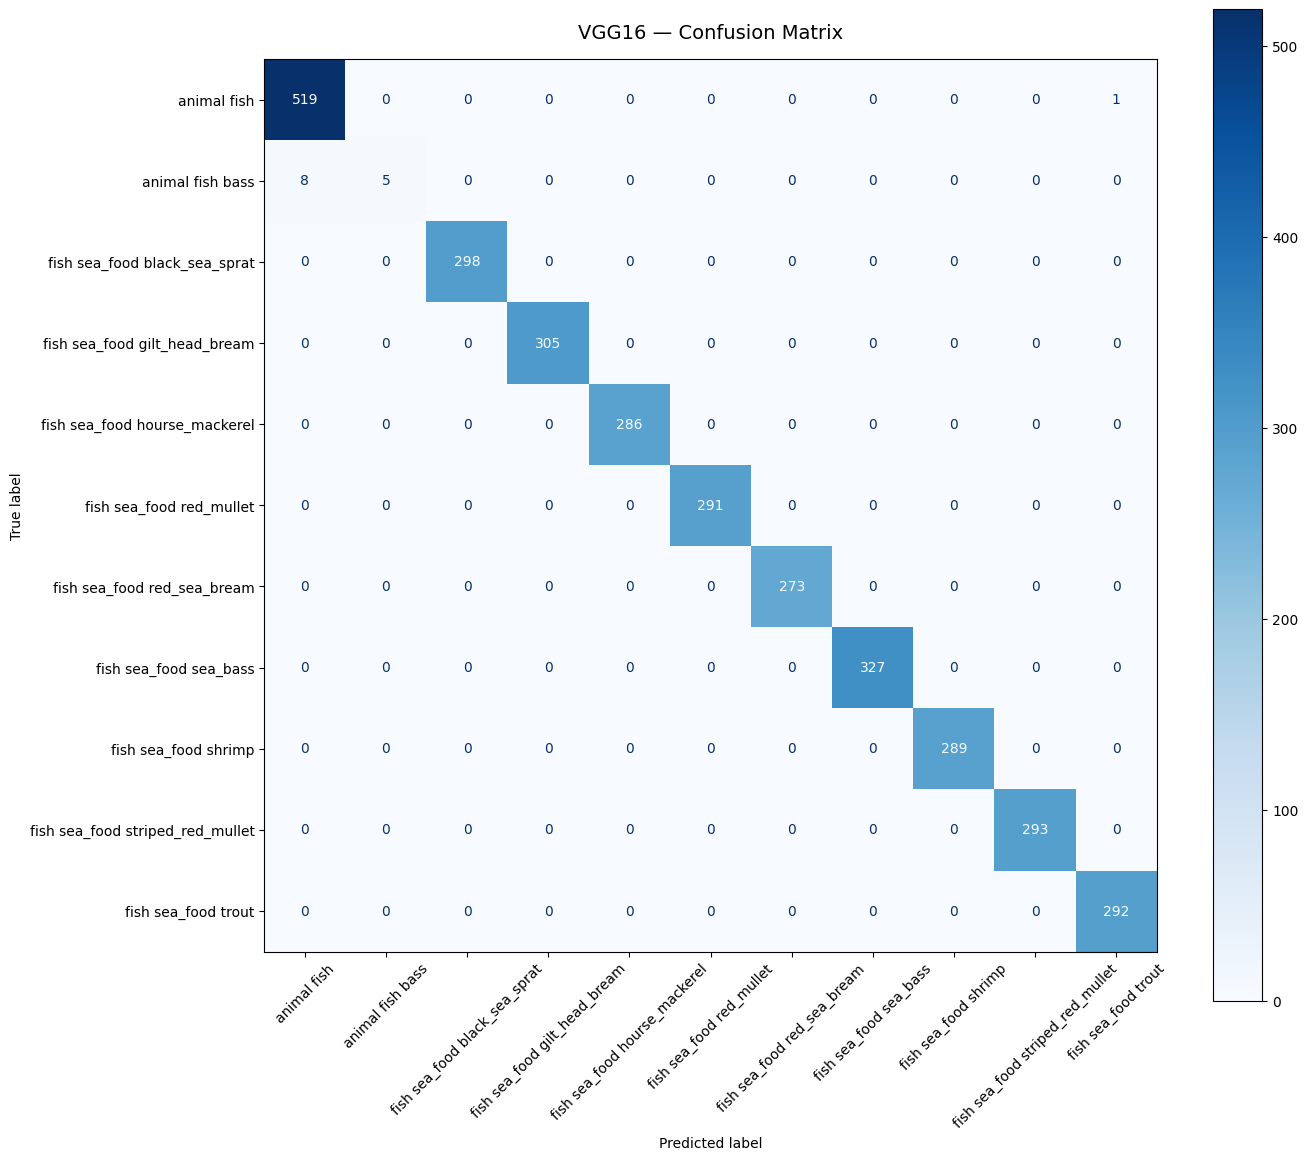

✅ Saved: saved_models/VGG16_confusion_matrix.png


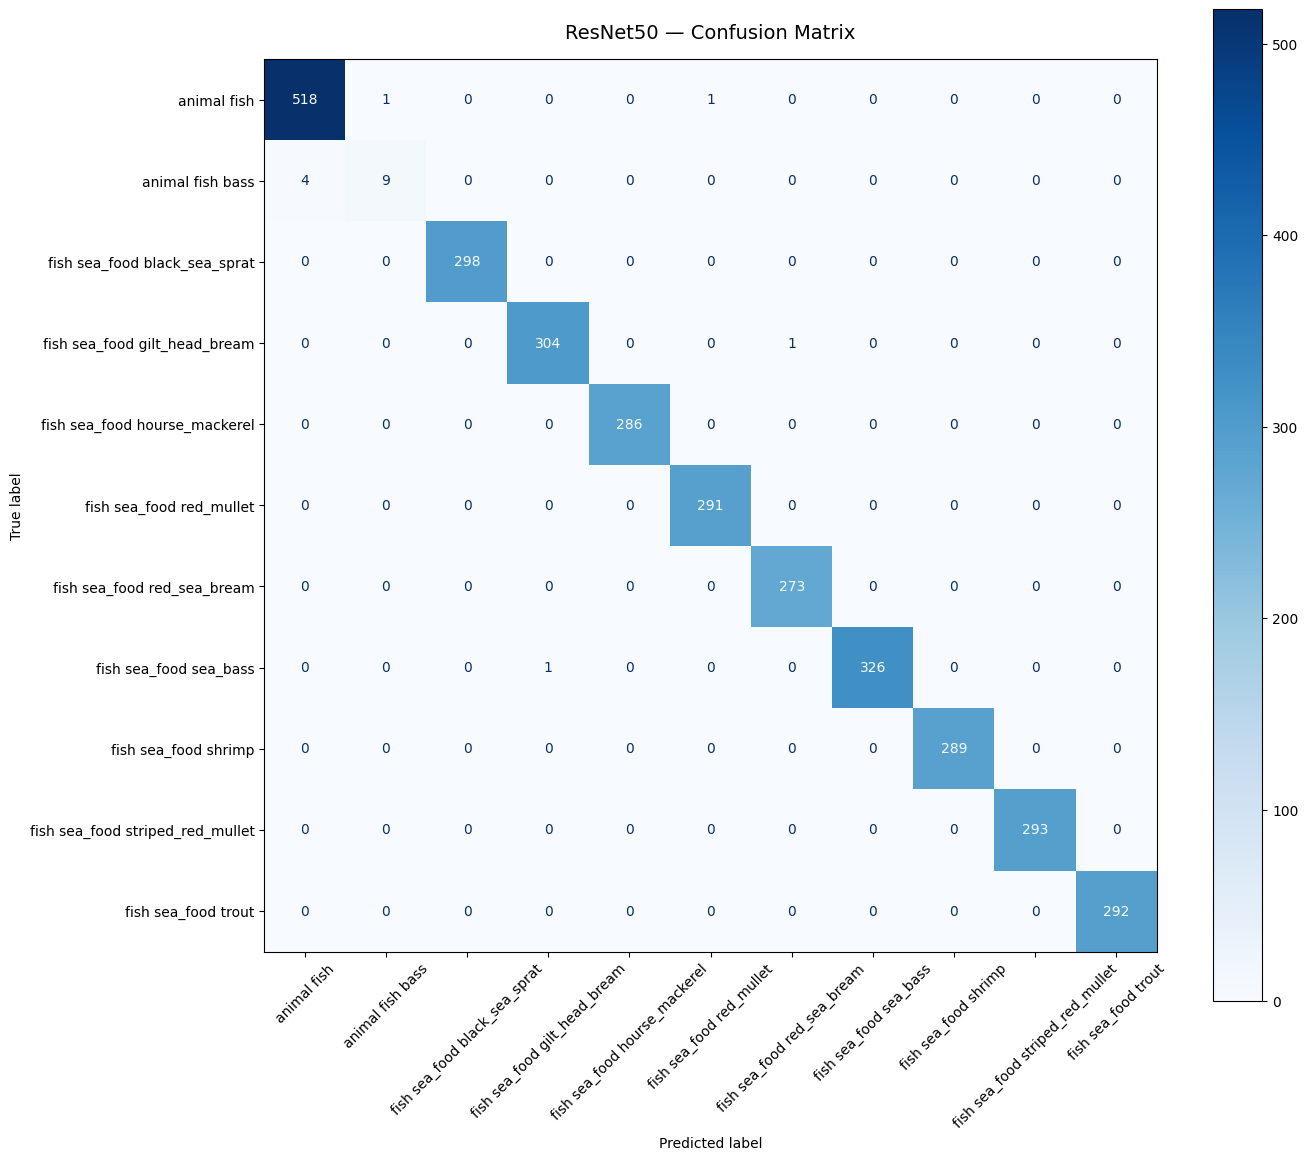

✅ Saved: saved_models/ResNet50_confusion_matrix.png


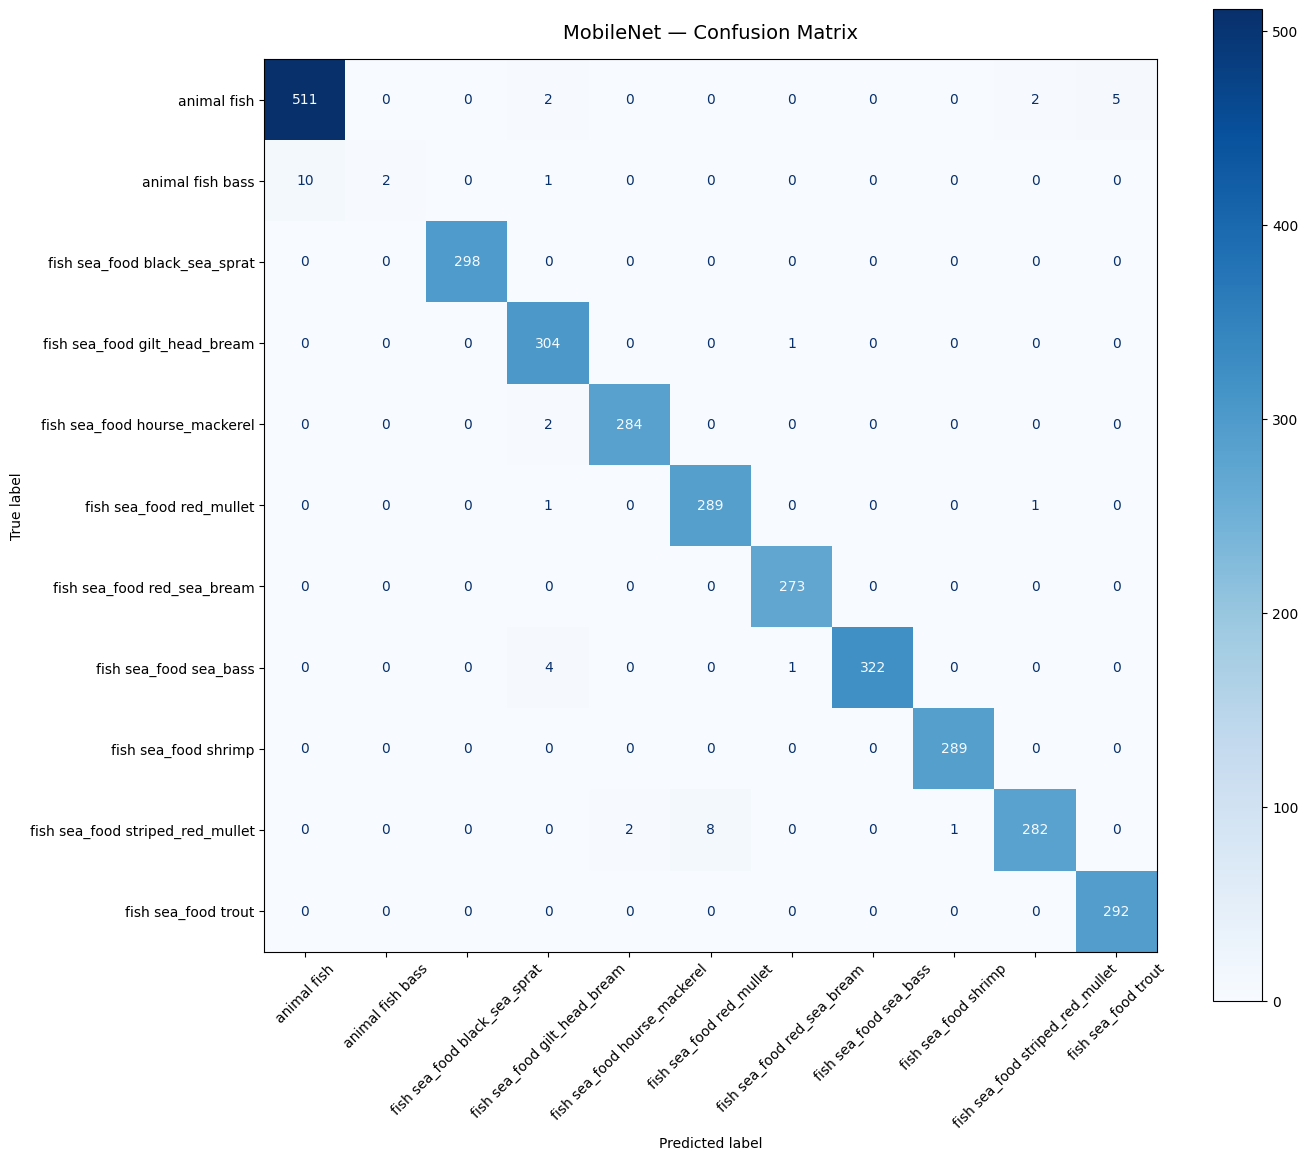

✅ Saved: saved_models/MobileNet_confusion_matrix.png


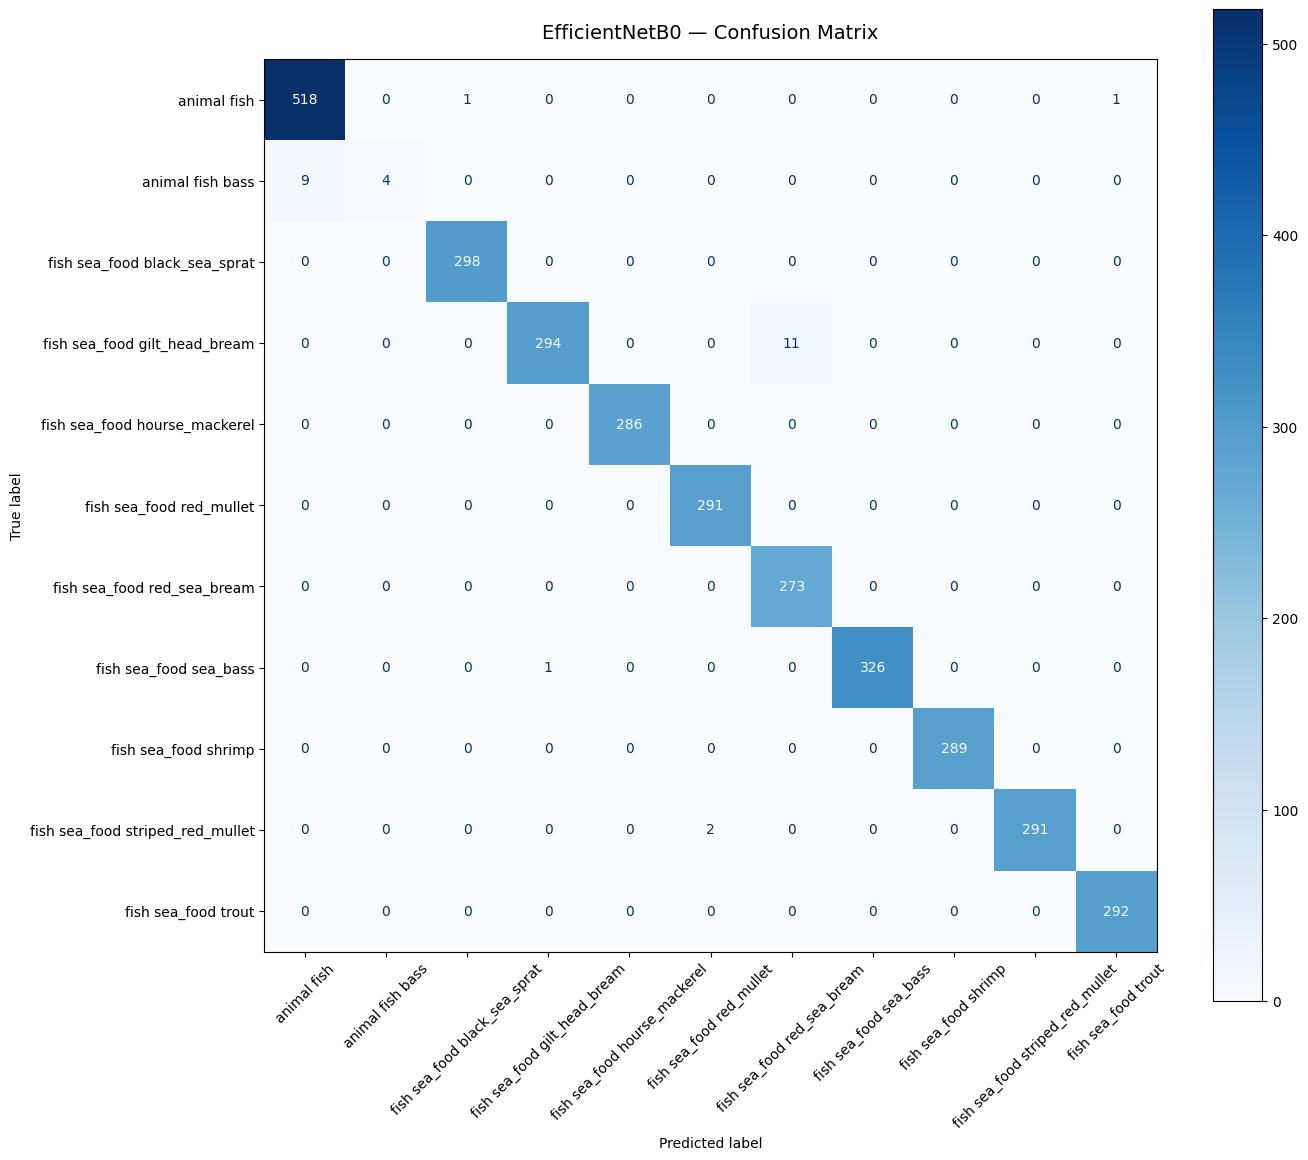

✅ Saved: saved_models/EfficientNetB0_confusion_matrix.png


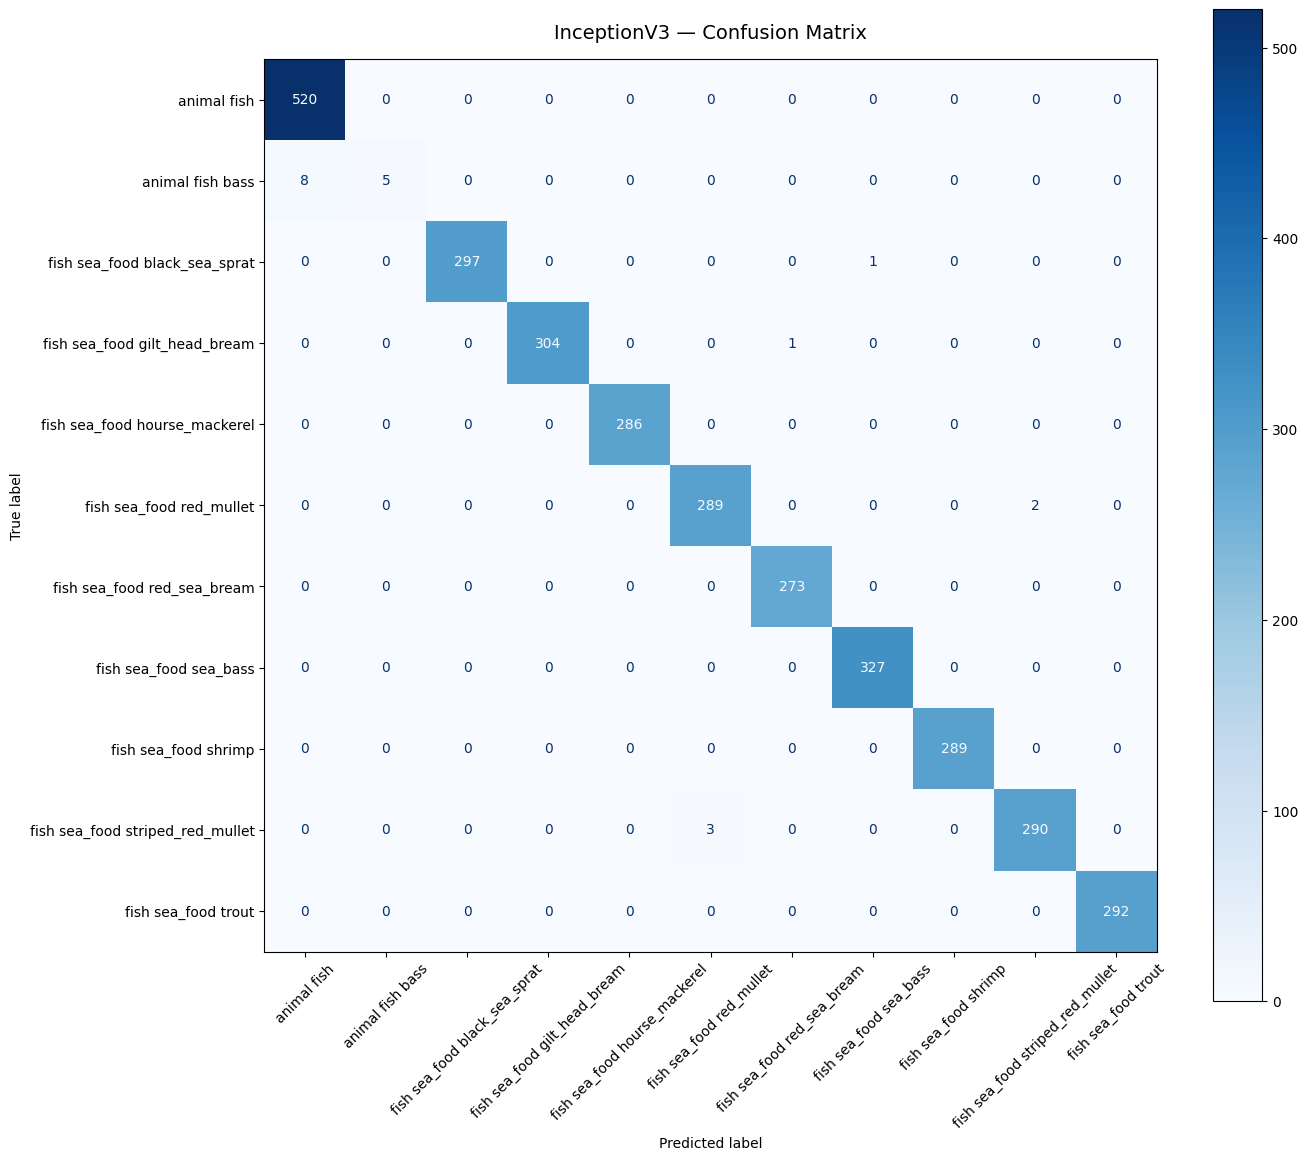

✅ Saved: saved_models/InceptionV3_confusion_matrix.png


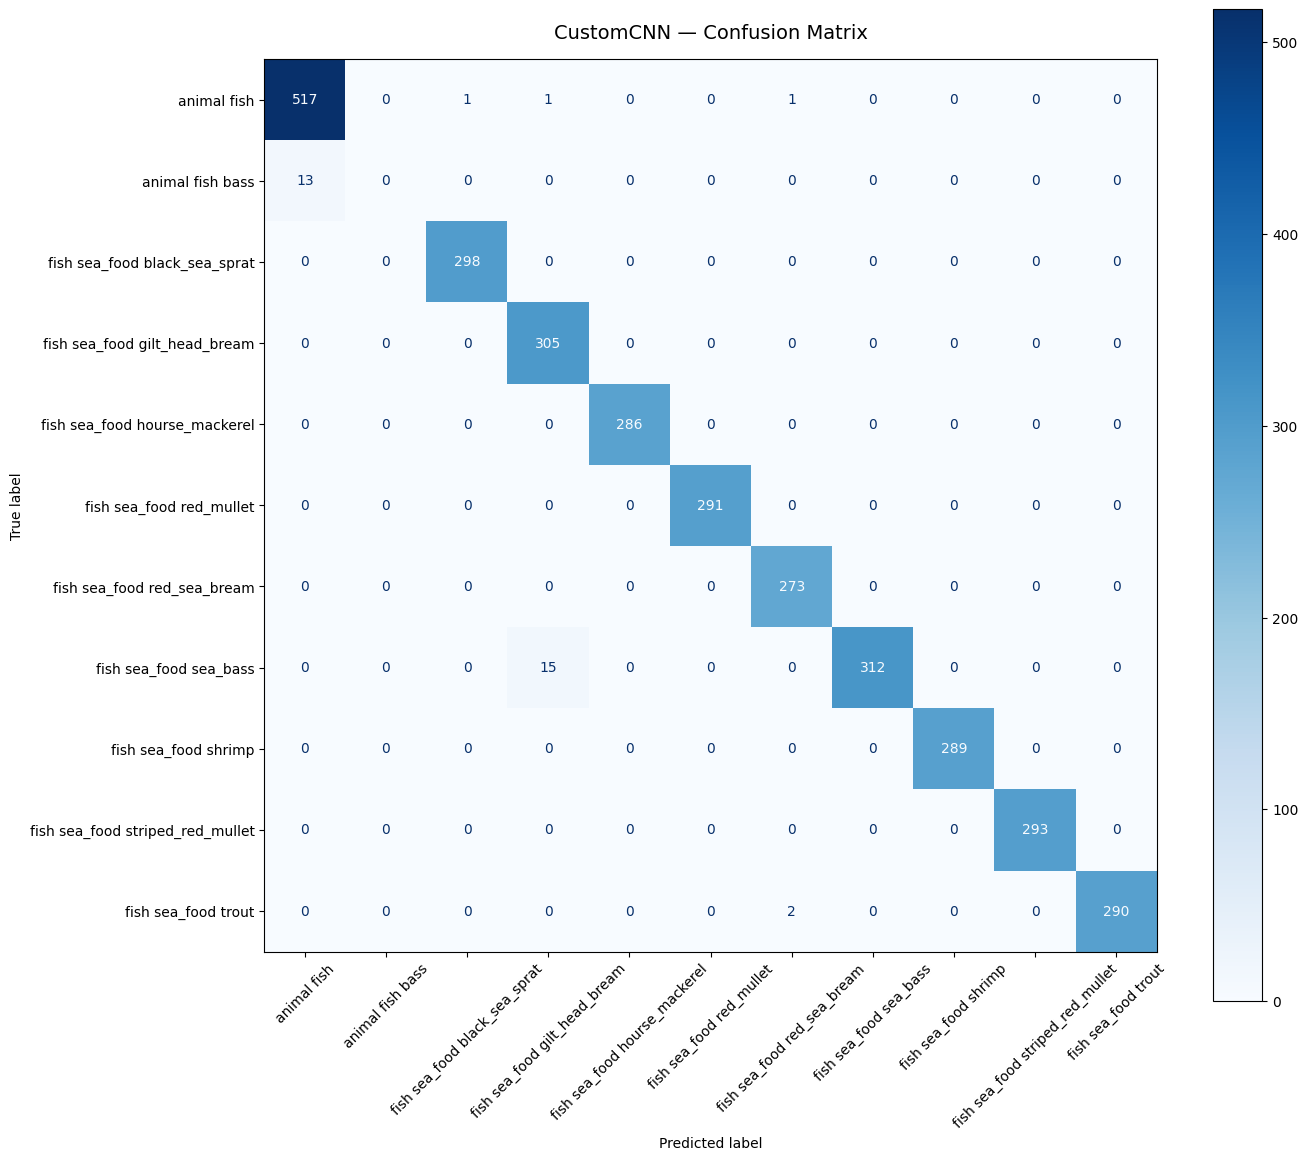

✅ Saved: saved_models/CustomCNN_confusion_matrix.png


In [68]:
for name, res in eval_results.items():
    plot_confusion_matrix(
        res['y_true'],
        res['y_pred'],
        name,
        CLASS_NAMES
    )


In [69]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print(f"\n{'='*75}")
print(f"  📊 FINAL MODEL COMPARISON TABLE")
print(f"{'='*75}")
print(f"  {'Model':<18} {'Test Acc':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"  {'-'*68}")

comparison = []

for name, res in eval_results.items():
    y_true = res['y_true']
    y_pred = res['y_pred']

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    comparison.append({
        "Model"    : name,
        "Accuracy" : acc,
        "Precision": prec,
        "Recall"   : rec,
        "F1-Score" : f1
    })

    print(f"  {name:<18} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

# Sort by F1-Score
comparison.sort(key=lambda x: x['F1-Score'], reverse=True)

print(f"\n🏆 Best Model by F1-Score : {comparison[0]['Model']}")
print(f"🎯 F1-Score               : {comparison[0]['F1-Score']:.4f}")



  📊 FINAL MODEL COMPARISON TABLE
  Model                Test Acc  Precision     Recall   F1-Score
  --------------------------------------------------------------------
  VGG16                  0.9972     0.9972     0.9972     0.9966
  ResNet50               0.9975     0.9974     0.9975     0.9974
  MobileNet              0.9871     0.9873     0.9871     0.9859
  EfficientNetB0         0.9922     0.9923     0.9922     0.9914
  InceptionV3            0.9953     0.9953     0.9953     0.9947
  CustomCNN              0.9896     0.9859     0.9896     0.9876

🏆 Best Model by F1-Score : ResNet50
🎯 F1-Score               : 0.9974


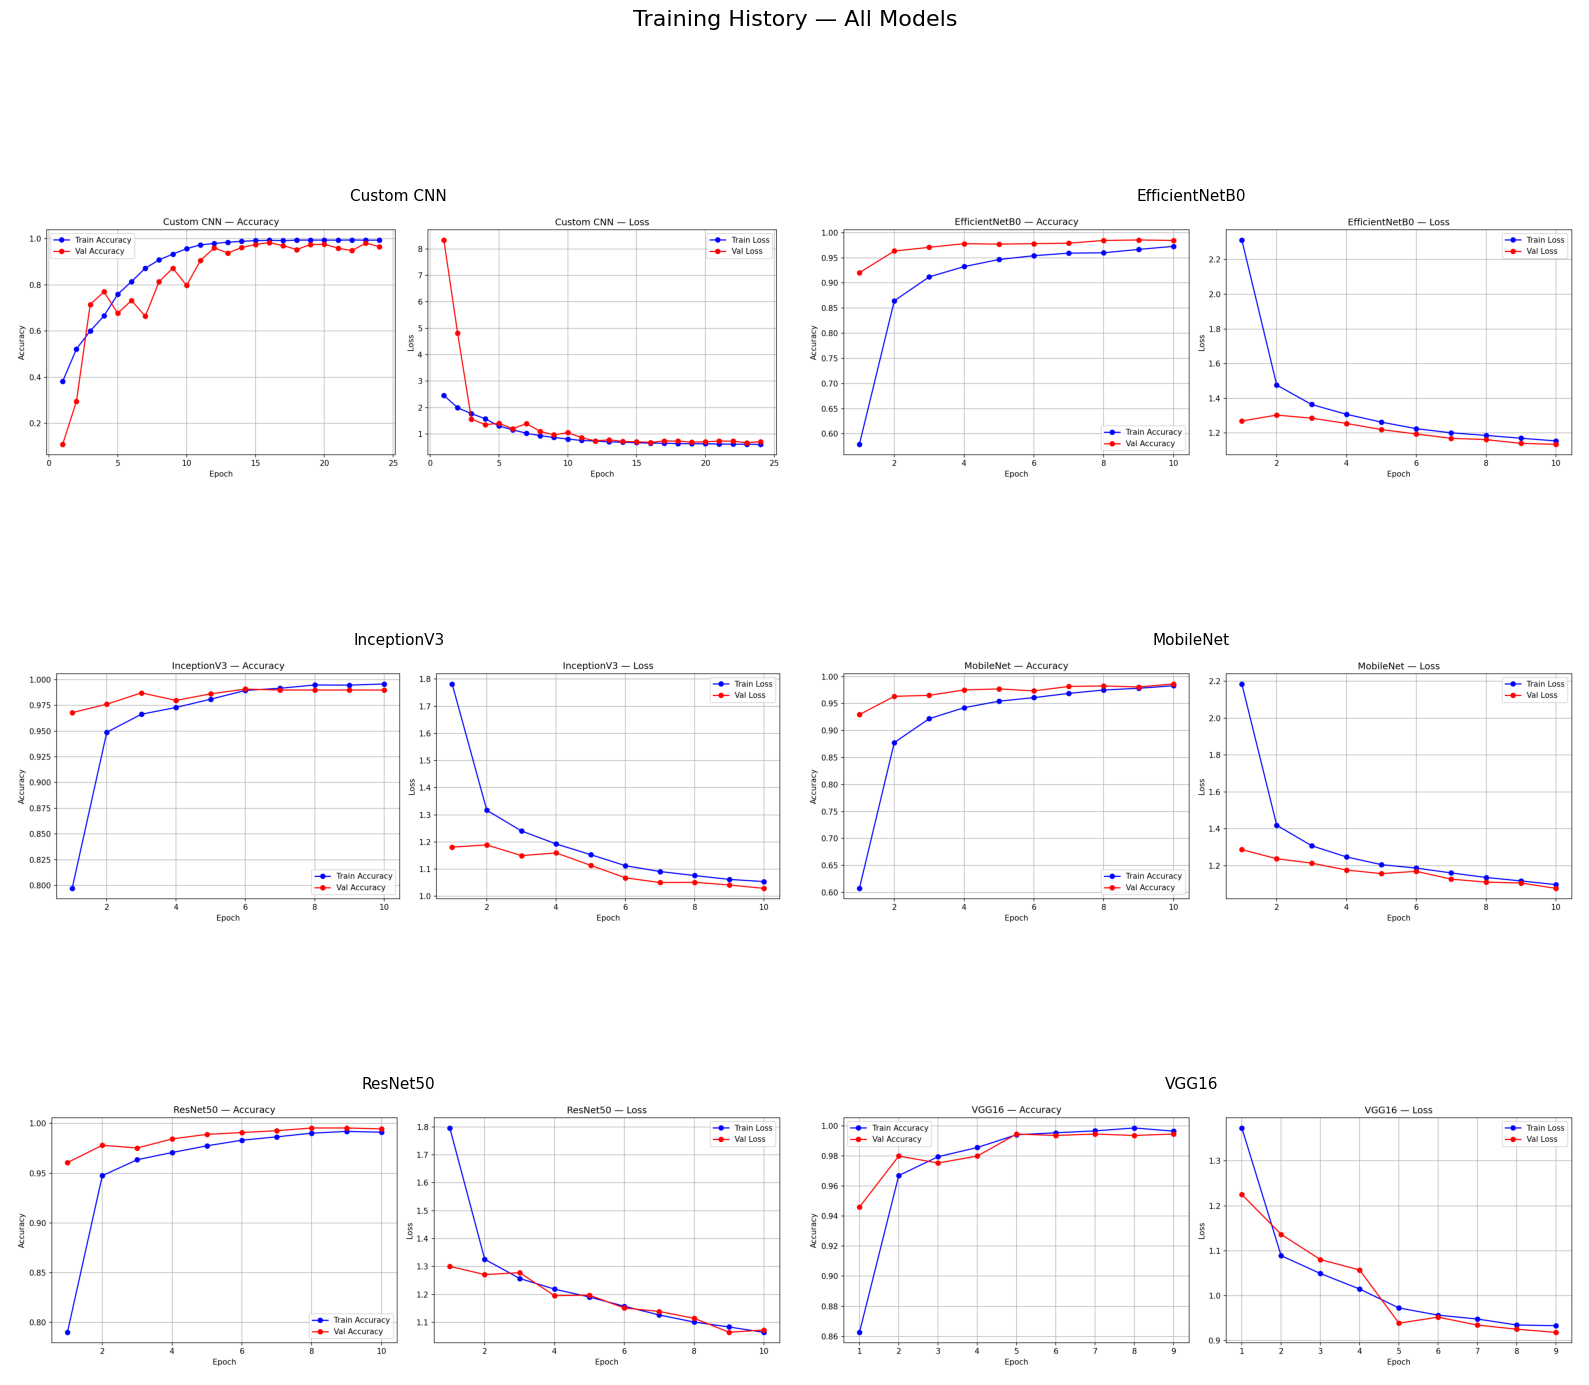

✅ Saved: saved_models/all_histories_combined.png


In [70]:
# NOTE: histories dict must be built during training
# Add this line at end of each model training:
# histories[model_name] = history  ← we collect below

# Collect all saved history plots into one comparison figure
history_files = [
    f for f in os.listdir("saved_models")
    if f.endswith("_history.png") and "phase" not in f
]

n = len(history_files)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 5))
axes = axes.flatten()

for i, fname in enumerate(sorted(history_files)):
    img = plt.imread(f"saved_models/{fname}")
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(fname.replace("_history.png", ""), fontsize=11)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Training History — All Models", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("saved_models/all_histories_combined.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: saved_models/all_histories_combined.png")


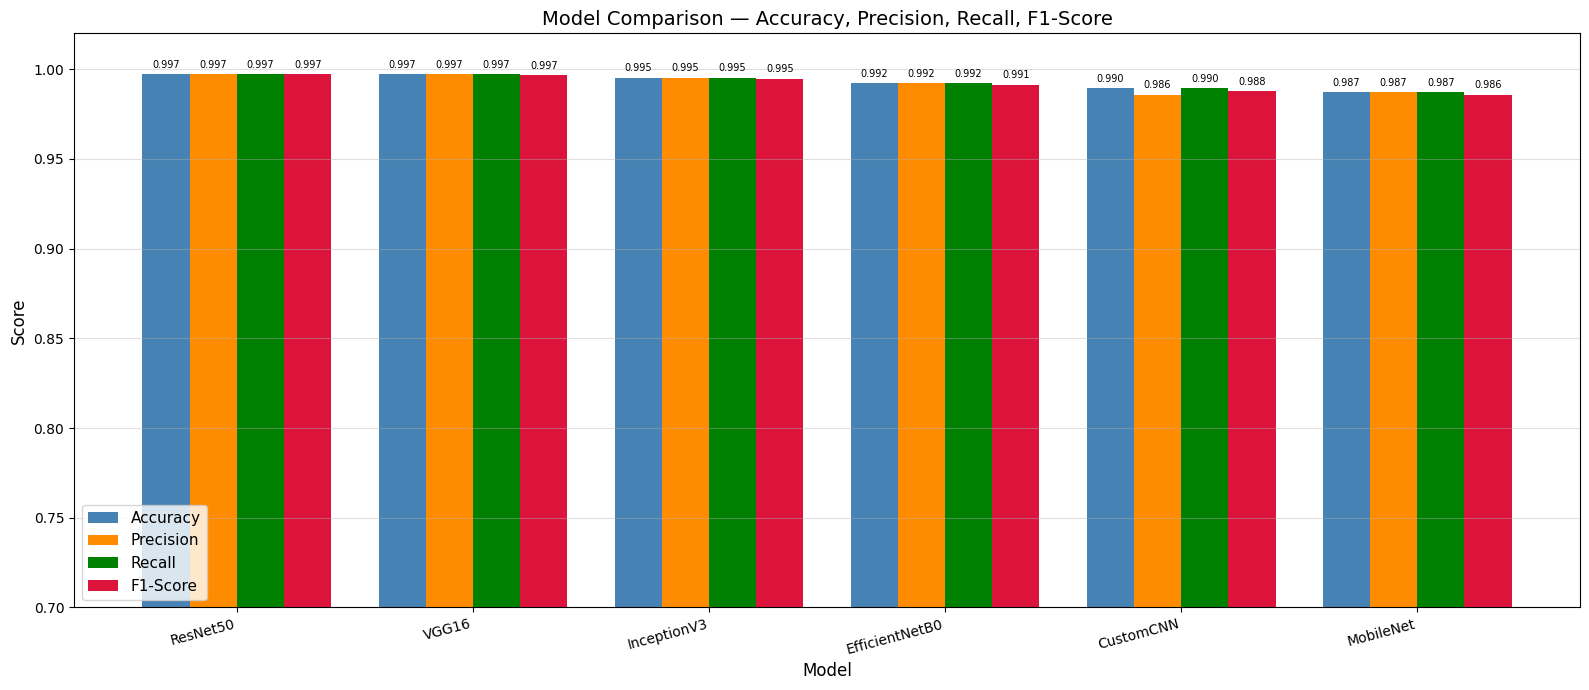

✅ Saved: saved_models/model_comparison_chart.png


In [71]:
import matplotlib.pyplot as plt
import numpy as np

models    = [c['Model']     for c in comparison]
accuracy  = [c['Accuracy']  for c in comparison]
precision = [c['Precision'] for c in comparison]
recall    = [c['Recall']    for c in comparison]
f1        = [c['F1-Score']  for c in comparison]

x     = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='steelblue')
bars2 = ax.bar(x - 0.5*width, precision, width, label='Precision', color='darkorange')
bars3 = ax.bar(x + 0.5*width, recall,    width, label='Recall',    color='green')
bars4 = ax.bar(x + 1.5*width, f1,        width, label='F1-Score',  color='crimson')

ax.set_xlabel('Model',    fontsize=12)
ax.set_ylabel('Score',    fontsize=12)
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1-Score', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0.7, 1.02)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

# Value labels on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig("saved_models/model_comparison_chart.png", dpi=150)
plt.show()
print("✅ Saved: saved_models/model_comparison_chart.png")


In [72]:
print(train_ds.class_names)

['animal fish', 'animal fish bass', 'fish sea_food black_sea_sprat', 'fish sea_food gilt_head_bream', 'fish sea_food hourse_mackerel', 'fish sea_food red_mullet', 'fish sea_food red_sea_bream', 'fish sea_food sea_bass', 'fish sea_food shrimp', 'fish sea_food striped_red_mullet', 'fish sea_food trout']
